In [3]:
!pip install tensorflow

import numpy as np
import time
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 5.0/351.2 MB 27.2 MB/s eta 0:00:13
   - -------------------------------------- 10.7/351.2 MB 27.3 MB/s eta 0:00:13
   - -------------------------------------- 16.5/351.2 MB 27.2 MB/s eta 0:00:13
   -- ------------------------------------- 22.3/351.2 MB 27

In [4]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [5]:
vocab_size = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [6]:
def build_model(model_type):
    model = Sequential()
    
    model.add(Embedding(vocab_size, 128, input_length=max_len))
    
    if model_type == "RNN":
        model.add(SimpleRNN(32))
    elif model_type == "LSTM":
        model.add(LSTM(32))
    elif model_type == "GRU":
        model.add(GRU(32))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

In [7]:
models = ["RNN", "LSTM", "GRU"]
results = {}

for m in models:
    print(f"\nTraining {m} model...")
    
    model = build_model(m)
    
    start_time = time.time()
    
    history = model.fit(
        X_train, y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )
    
    training_time = time.time() - start_time
    
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    results[m] = {
        "accuracy": accuracy,
        "time": training_time,
        "history": history
    }


Training RNN model...
Epoch 1/3


c:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.7103 - loss: 0.5363 - val_accuracy: 0.7420 - val_loss: 0.5124
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.8722 - loss: 0.3139 - val_accuracy: 0.7940 - val_loss: 0.4476
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.9201 - loss: 0.2102 - val_accuracy: 0.8266 - val_loss: 0.4553

Training LSTM model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - accuracy: 0.7890 - loss: 0.4538 - val_accuracy: 0.8556 - val_loss: 0.3493
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.8939 - loss: 0.2682 - val_accuracy: 0.8596 - val_loss: 0.3360
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 133ms/step - accuracy: 0.9324 - loss: 0.1854 - val_accuracy: 0.8742 - val_loss: 0.3367

Training GRU model...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 139ms/step - accuracy: 0.7704 - loss: 0.4608 - val_accuracy: 0.8572 - val_loss: 0.3414
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - 


=== Model Comparison ===
RNN -> Accuracy: 0.8274, Time: 56.28s
LSTM -> Accuracy: 0.8684, Time: 120.56s
GRU -> Accuracy: 0.8668, Time: 142.41s


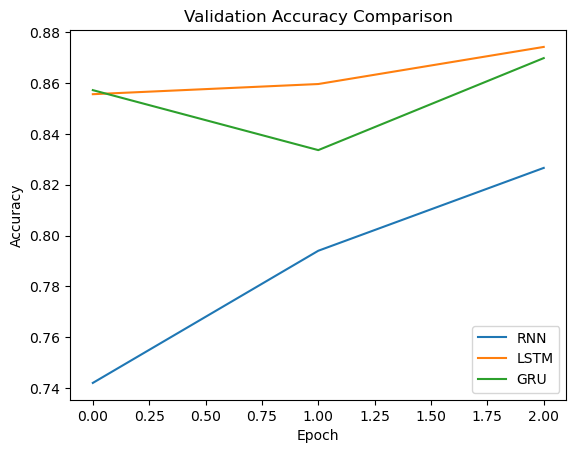

In [8]:
print("\n=== Model Comparison ===")
for m in results:
    print(f"{m} -> Accuracy: {results[m]['accuracy']:.4f}, Time: {results[m]['time']:.2f}s")

for m in results:
    plt.plot(results[m]['history'].history['val_accuracy'], label=m)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()